# EpiSentinel — Task 2: LSTM Outbreak Early Warning Model

**Objective:** Build and evaluate an LSTM-based time series model to detect epidemic outbreaks
one week ahead using aggregated weekly case data.

**Input:** `weekly_cases_enhanced.csv` — 994,276 rows × 25 columns  
**Target:** `label_outbreak_week` — binary (1 = outbreak week, 0 = normal)  
**Output:** Trained model, scalers, threshold, and evaluation metrics


In [20]:
# ===================== 0) Setup =====================

from google.colab import drive

drive.mount('/content/drive')



import os, json, time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import joblib





BASE_DIR   = "/content/drive/MyDrive/EPisentinel"

DATA_PATH  = f"{BASE_DIR}/data/weekly_cases_enhanced.csv"

OUT_DIR    = f"{BASE_DIR}/Model 4"  # new folder -- Model 2 cache/checkpoints do not match
                                     # the disease-filtered pipeline below

# Diseases with too few outbreak_week=1 rows across the whole dataset are close to pure
# negative noise for this task (a handful of positives can't teach a per-disease pattern).
# Drop them before training unless testing cross-disease transfer.
MIN_POSITIVE_EVENTS_PER_DISEASE = 50   # Typhoid fever (27) and the zero-outbreak diseases fall below this
EXCLUDE_ZERO_OUTBREAK_DISEASES = True   # kept for backward compatibility, superseded by the line above



CKPT_DIR = f"{OUT_DIR}/checkpoints"

ART_DIR  = f"{OUT_DIR}/artifacts"

RES_DIR  = f"{OUT_DIR}/results"

for d in [CKPT_DIR, ART_DIR, RES_DIR]:

    os.makedirs(d, exist_ok=True)



WINDOWS_CACHE   = f"{CKPT_DIR}/windows_cache.npz"

LAST_MODEL_PATH = f"{CKPT_DIR}/last_epoch.keras"

BEST_MODEL_PATH = f"{CKPT_DIR}/best_model.keras"

HISTORY_CSV     = f"{CKPT_DIR}/training_history.csv"

ENCODERS_PATH   = f"{ART_DIR}/encoders.joblib"

SCALERS_PATH    = f"{ART_DIR}/scalers.joblib"

THRESHOLD_PATH  = f"{ART_DIR}/best_threshold.json"



print("Data path  :", DATA_PATH)

print("Output dir :", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path  : /content/drive/MyDrive/EPisentinel/data/weekly_cases_enhanced.csv
Output dir : /content/drive/MyDrive/EPisentinel/Model 4


In [21]:
# Setup — install dependencies and import all required libraries
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, confusion_matrix,
                              classification_report)

tf.random.set_seed(42)
np.random.seed(42)
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
# Install packages (silent) and configure GPU if available
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)

missing = df.isnull().sum()
total_missing = missing.sum()
print("Total missing values:", total_missing)
if total_missing > 0:
    print(missing[missing > 0])

expected_cols = ['COUNTRY','CITY','DISEASE','VISIT_WEEK_START','VISIT_YEAR','VISIT_MONTH',
                  'SEASON','LAT','LON','case_count','outbreak_cases','avg_age','avg_comorbidity',
                  'lag_1_cases','lag_2_cases','lag_3_cases','lag_4_cases','cases_2wk_avg',
                  'cases_3wk_avg','cases_4wk_avg','cases_4wk_std','cases_diff','pct_change_wow',
                  'growth_rate','label_outbreak_week']
missing_cols = set(expected_cols) - set(df.columns)
assert not missing_cols, f"Missing expected columns: {missing_cols}"

print("All expected columns are present")
print("Series count (COUNTRY,CITY,DISEASE):", df.groupby(['COUNTRY','CITY','DISEASE']).ngroups)
print("Positive label ratio:", df['label_outbreak_week'].mean())

# --- Per-disease outbreak rate diagnostic ---
# This dataset has diseases with literally zero outbreak weeks recorded anywhere.
# Those series are pure negative noise for THIS task (though they may still carry
# useful general case-count patterns for other purposes) -- surface it explicitly
# instead of silently training on it.
disease_rates = df.groupby("DISEASE")["label_outbreak_week"].agg(["mean", "sum", "count"])
disease_rates = disease_rates.sort_values("mean", ascending=False)
print("\nOutbreak rate by disease:")
print(disease_rates)

low_signal_diseases = disease_rates.index[disease_rates["sum"] < MIN_POSITIVE_EVENTS_PER_DISEASE].tolist()
print(f"\nDiseases with fewer than {MIN_POSITIVE_EVENTS_PER_DISEASE} outbreak events total "
      f"(too sparse to learn a per-disease pattern): {low_signal_diseases}")

if EXCLUDE_ZERO_OUTBREAK_DISEASES and low_signal_diseases:
    rows_before = len(df)
    df = df[~df["DISEASE"].isin(low_signal_diseases)].reset_index(drop=True)
    print(f"Dropped {rows_before - len(df)} rows ({(rows_before - len(df)) / rows_before:.1%}) "
          f"belonging to {len(low_signal_diseases)} low-signal diseases.")
    print("Shape after filtering:", df.shape)
    print("Positive label ratio after filtering:", df["label_outbreak_week"].mean())


Shape: (983425, 25)
Total missing values: 0
All expected columns are present
Series count (COUNTRY,CITY,DISEASE): 751
Positive label ratio: 0.0036200015252815416

Outbreak rate by disease:
                         mean  sum  count
DISEASE                                  
Ebola virus disease  0.011769   65   5523
Cholera              0.009239  817  88433
Mpox                 0.008679   36   4148
Malaria              0.008435  746  88443
Lassa fever          0.008072   67   8300
COVID-19             0.007654  162  21165
Meningitis           0.006694  591  88290
Rift Valley fever    0.005794   24   4142
Influenza            0.005624  498  88542
Dengue fever         0.004586  152  33146
Measles              0.004270  375  87820
Typhoid fever        0.000305   27  88460
Diarrheal disease    0.000000    0  67688
HIV/AIDS             0.000000    0  44047
Leishmaniasis        0.000000    0   5526
Hepatitis A          0.000000    0  88360
Pneumonia            0.000000    0  82916
Tuberculosis 

In [23]:
# Load weekly dataset — raise immediately if missing values are detected
GROUP_COLS = ["COUNTRY", "CITY", "DISEASE"]
DATE_COL = "VISIT_WEEK_START"

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(GROUP_COLS + [DATE_COL]).reset_index(drop=True)

# --- Static categoricals -> label encode (for embeddings later) ---
le_country = LabelEncoder(); df["COUNTRY_enc"] = le_country.fit_transform(df["COUNTRY"])
le_city    = LabelEncoder(); df["CITY_enc"]    = le_city.fit_transform(df["CITY"])
le_disease = LabelEncoder(); df["DISEASE_enc"] = le_disease.fit_transform(df["DISEASE"])
le_season  = LabelEncoder(); df["SEASON_enc"]  = le_season.fit_transform(df["SEASON"])

N_COUNTRY = df["COUNTRY_enc"].nunique()
N_CITY    = df["CITY_enc"].nunique()
N_DISEASE = df["DISEASE_enc"].nunique()
N_SEASON  = df["SEASON_enc"].nunique()
print("Vocab sizes -> country:", N_COUNTRY, "city:", N_CITY, "disease:", N_DISEASE, "season:", N_SEASON)

# --- Cyclical month encoding ---
df["month_sin"] = np.sin(2 * np.pi * df["VISIT_MONTH"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["VISIT_MONTH"] / 12)

# --- Target = label_outbreak_week shifted -1 within each series (early warning: predict NEXT week) ---
df["target_next_week"] = df.groupby(GROUP_COLS)["label_outbreak_week"].shift(-1)
df = df.dropna(subset=["target_next_week"]).reset_index(drop=True)
df["target_next_week"] = df["target_next_week"].astype(int)

print("Rows after dropping last-per-series (NaN target):", len(df))
print("Target positive ratio: {:.4%}".format(df["target_next_week"].mean()))

# --- Save encoders immediately (cheap, no reason to risk losing them) ---
joblib.dump(
    {"country": le_country, "city": le_city, "disease": le_disease, "season": le_season},
    ENCODERS_PATH
)
print("Encoders saved ->", ENCODERS_PATH)


Vocab sizes -> country: 19 city: 64 disease: 9 season: 4
Rows after dropping last-per-series (NaN target): 509254
Target positive ratio: 0.6818%
Encoders saved -> /content/drive/MyDrive/EPisentinel/Model 4/artifacts/encoders.joblib


In [24]:
# Feature engineering: encode categoricals, add cyclical month features, shift target by one week
# Fully vectorized (no groupby.apply) — avoids the pandas-version-dependent
# `include_groups` keyword that only exists from pandas 2.2 onward.
group_size   = df.groupby(GROUP_COLS)[DATE_COL].transform("size")
row_in_group = df.groupby(GROUP_COLS).cumcount()

train_end = (group_size * 0.70).astype(int)
val_end   = (group_size * 0.85).astype(int)

df["split"] = np.select(
    [row_in_group < train_end, row_in_group < val_end],
    ["train", "val"],
    default="test",
)

print(df["split"].value_counts())
print("\nPositive ratio per split:")
print(df.groupby("split")["target_next_week"].mean())


split
train    356297
test      76612
val       76345
Name: count, dtype: int64

Positive ratio per split:
split
test     0.004869
train    0.007247
val      0.006772
Name: target_next_week, dtype: float64


In [25]:
# Temporal split: 70% train / 15% validation / 15% test — vectorized, no groupby.apply
train_mask = df["split"] == "train"
scalers = {}

def fit_scale(col, out_col, log_transform=False, clip=None, own_scaler=True, shared_scaler_key=None):
    """Fit a StandardScaler on train rows only, transform the whole column."""
    work_col = col
    if clip is not None:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).clip(*clip).fillna(0)
    if log_transform:
        work_col = col + "_log"
        df[work_col] = np.log1p(df[col])

    if shared_scaler_key is not None and shared_scaler_key in scalers:
        sc = scalers[shared_scaler_key]
    else:
        sc = StandardScaler().fit(df.loc[train_mask, [work_col]])
        key = shared_scaler_key if shared_scaler_key is not None else out_col
        scalers[key] = sc

    df[out_col] = sc.transform(df[[work_col]])

# static numerics
fit_scale("VISIT_YEAR", "VISIT_YEAR_s")
fit_scale("LAT", "LAT_s")
fit_scale("LON", "LON_s")

# case_count family -> shared scaler (fit on case_count_log, reused for the 4 lags)
fit_scale("case_count", "case_count_s", log_transform=True, shared_scaler_key="case_count_log")
for lag_col in ["lag_1_cases", "lag_2_cases", "lag_3_cases", "lag_4_cases"]:
    df[lag_col + "_log"] = np.log1p(df[lag_col])
    df[lag_col + "_s"] = scalers["case_count_log"].transform(
        df[[lag_col + "_log"]].rename(columns={lag_col + "_log": "case_count_log"})
    )

fit_scale("avg_age", "avg_age_s")
fit_scale("avg_comorbidity", "avg_comorbidity_s")

for col in ["cases_2wk_avg", "cases_3wk_avg", "cases_4wk_avg", "cases_4wk_std"]:
    fit_scale(col, col + "_s", log_transform=True)

fit_scale("cases_diff", "cases_diff_s", clip=(-100, 100))                # clipped: raw values reach +-1600 in outbreak spikes
fit_scale("pct_change_wow", "pct_change_wow_s", clip=(-5, 5))
fit_scale("growth_rate", "growth_rate_s", clip=(-5, 5))

# --- CUSUM/EWMA-style anomaly z-score, computed from the 4 lag columns only (strictly
#     historical, no leakage from the current week) -- this is the classical surveillance
#     signal (WHO EWARS / CDC EARS use the same idea), given directly to the LSTM instead
#     of leaving it to infer the same thing indirectly from raw lags. Empirically far more
#     separated between classes than the existing cases_4wk_avg/std features, which are
#     computed over windows that include the current observation and so are less sensitive.
lag_cols = ["lag_1_cases", "lag_2_cases", "lag_3_cases", "lag_4_cases"]
lag_mean = df[lag_cols].mean(axis=1)
lag_std  = df[lag_cols].std(axis=1)
df["case_zscore"] = (df["case_count"] - lag_mean) / (lag_std + 1)
fit_scale("case_zscore", "case_zscore_s", clip=(-30, 30))

joblib.dump(scalers, SCALERS_PATH)
print("Scalers saved ->", SCALERS_PATH, "| count:", len(scalers))


Scalers saved -> /content/drive/MyDrive/EPisentinel/Model 4/artifacts/scalers.joblib | count: 14


In [26]:
# Scaling — StandardScaler fitted on train rows only, then applied to the full dataset
SEQ_LEN = 8

SEQ_NUMERIC_COLS = [
    "VISIT_YEAR_s", "month_sin", "month_cos",
    "case_count_s", "avg_age_s", "avg_comorbidity_s",
    "lag_1_cases_s", "lag_2_cases_s", "lag_3_cases_s", "lag_4_cases_s",
    "cases_2wk_avg_s", "cases_3wk_avg_s", "cases_4wk_avg_s", "cases_4wk_std_s",
    "cases_diff_s", "pct_change_wow_s", "growth_rate_s", "case_zscore_s"
]

if os.path.exists(WINDOWS_CACHE):
    print("Found cached windows, loading instead of recomputing:", WINDOWS_CACHE)
    cache = np.load(WINDOWS_CACHE, allow_pickle=True)
    X_seq_numeric = cache["X_seq_numeric"]
    X_season      = cache["X_season"]
    X_country     = cache["X_country"]
    X_city        = cache["X_city"]
    X_disease     = cache["X_disease"]
    X_latlon      = cache["X_latlon"]
    y_all         = cache["y_all"]
    split_all     = cache["split_all"]
    target_dates  = cache["target_dates"]
    group_all     = cache["group_all"]
else:
    print("No cache found — building windows from scratch (this runs once).")

    def build_windows_for_group(g):
        n = len(g)
        if n < SEQ_LEN:
            return None
        seq_numeric = g[SEQ_NUMERIC_COLS].values.astype(np.float32)
        season_seq  = g["SEASON_enc"].values.astype(np.int32)
        target      = g["target_next_week"].values.astype(np.int8)
        split_col   = g["split"].values
        dates       = g[DATE_COL].values

        country_id = g["COUNTRY_enc"].iloc[0]
        city_id    = g["CITY_enc"].iloc[0]
        disease_id = g["DISEASE_enc"].iloc[0]
        lat_s      = g["LAT_s"].iloc[0]
        lon_s      = g["LON_s"].iloc[0]

        n_windows = n - SEQ_LEN + 1
        out = {"seq_numeric": [], "season_seq": [], "country": [], "city": [], "disease": [],
               "lat_lon": [], "y": [], "split": [], "target_date": [], "group": []}
        group_key = f"{g['COUNTRY'].iloc[0]}|{g['CITY'].iloc[0]}|{g['DISEASE'].iloc[0]}"

        for i in range(n_windows):
            end = i + SEQ_LEN - 1
            out["seq_numeric"].append(seq_numeric[i:i+SEQ_LEN])
            out["season_seq"].append(season_seq[i:i+SEQ_LEN])
            out["country"].append(country_id)
            out["city"].append(city_id)
            out["disease"].append(disease_id)
            out["lat_lon"].append([lat_s, lon_s])
            out["y"].append(target[end])
            out["split"].append(split_col[end])
            out["target_date"].append(dates[end])
            out["group"].append(group_key)
        return out

    all_data = {k: [] for k in ["seq_numeric", "season_seq", "country", "city",
                                 "disease", "lat_lon", "y", "split", "target_date", "group"]}
    for keys, g in df.groupby(GROUP_COLS):
        res = build_windows_for_group(g)
        if res is None:
            continue
        for k in all_data:
            all_data[k].extend(res[k])

    X_seq_numeric = np.array(all_data["seq_numeric"], dtype=np.float32)
    X_season      = np.array(all_data["season_seq"], dtype=np.int32)
    X_country     = np.array(all_data["country"], dtype=np.int32)
    X_city        = np.array(all_data["city"], dtype=np.int32)
    X_disease     = np.array(all_data["disease"], dtype=np.int32)
    X_latlon      = np.array(all_data["lat_lon"], dtype=np.float32)
    y_all         = np.array(all_data["y"], dtype=np.int8)
    split_all     = np.array(all_data["split"])
    target_dates  = np.array(all_data["target_date"])
    group_all     = np.array(all_data["group"])

    np.savez_compressed(
        WINDOWS_CACHE,
        X_seq_numeric=X_seq_numeric, X_season=X_season, X_country=X_country,
        X_city=X_city, X_disease=X_disease, X_latlon=X_latlon, y_all=y_all,
        split_all=split_all, target_dates=target_dates, group_all=group_all,
    )
    print("Windows cached ->", WINDOWS_CACHE)

print("Sequence input shape:", X_seq_numeric.shape)
print("Split counts:", pd.Series(split_all).value_counts().to_dict())
print("Positive ratio per split:")
print(pd.Series(y_all).groupby(split_all).mean())


Found cached windows, loading instead of recomputing: /content/drive/MyDrive/EPisentinel/Model 4/checkpoints/windows_cache.npz
Sequence input shape: (506398, 8, 18)
Split counts: {'train': 353441, 'test': 76612, 'val': 76345}
Positive ratio per split:
test     0.004869
train    0.007198
val      0.006772
dtype: float64


In [27]:
# Windowing — build (sequence, target) pairs per city-disease series; cache to disk
def subset(mask):
    return {
        "seq_numeric": X_seq_numeric[mask], "season": X_season[mask],
        "country": X_country[mask], "city": X_city[mask], "disease": X_disease[mask],
        "latlon": X_latlon[mask], "y": y_all[mask],
    }

train_data = subset(split_all == "train")
val_data   = subset(split_all == "val")
test_data  = subset(split_all == "test")

def to_input_dict(d):
    return {"seq_numeric": d["seq_numeric"], "season_seq": d["season"],
            "country": d["country"], "city": d["city"], "disease": d["disease"], "latlon": d["latlon"]}

print("Train:", train_data["y"].shape, "| Val:", val_data["y"].shape, "| Test:", test_data["y"].shape)


Train: (353441,) | Val: (76345,) | Test: (76612,)


In [28]:
# Subset arrays into train / validation / test dictionaries
def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss_fn

FOCAL_GAMMA, FOCAL_ALPHA = 2.0, 0.75  # matches Ya7ya's original setting; used together with the
                                       # sqrt-softened class_weight below (as in the original)

def build_model(seq_len, n_seq_features, units1=64, units2=32, dropout=0.3, lr=0.001):
    seq_input    = layers.Input(shape=(seq_len, n_seq_features), name="seq_numeric")
    season_input = layers.Input(shape=(seq_len,), name="season_seq")

    season_emb = layers.Embedding(input_dim=N_SEASON, output_dim=4, name="season_emb")(season_input)
    seq_combined = layers.Concatenate(axis=-1)([seq_input, season_emb])

    x = layers.Bidirectional(layers.LSTM(units1, return_sequences=True))(seq_combined)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units2)(x)
    x = layers.Dropout(dropout)(x)

    # Static inputs -> injected ONCE, after the LSTM (not repeated per timestep)
    country_input = layers.Input(shape=(1,), name="country")
    city_input    = layers.Input(shape=(1,), name="city")
    disease_input = layers.Input(shape=(1,), name="disease")
    latlon_input  = layers.Input(shape=(2,), name="latlon")

    country_emb = layers.Flatten()(layers.Embedding(N_COUNTRY, 8)(country_input))
    city_emb    = layers.Flatten()(layers.Embedding(N_CITY, 16)(city_input))
    disease_emb = layers.Flatten()(layers.Embedding(N_DISEASE, 8)(disease_input))

    static_concat = layers.Concatenate()([country_emb, city_emb, disease_emb, latlon_input])
    static_dense = layers.Dense(16, activation="relu")(static_concat)

    combined = layers.Concatenate()([x, static_dense])
    combined = layers.Dense(16, activation="relu")(combined)
    output = layers.Dense(1, activation="sigmoid")(combined)

    model = Model(
        inputs=[seq_input, season_input, country_input, city_input, disease_input, latlon_input],
        outputs=output
    )
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )
    return model

CUSTOM_OBJECTS = {"loss_fn": focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)}
n_seq_features = X_seq_numeric.shape[2]
model = build_model(SEQ_LEN, n_seq_features)
model.summary()

# Class weights — softened with sqrt to avoid over-correcting the imbalance
# Used alongside focal loss for double regularization on the minority class
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_data["y"])
cw = compute_class_weight("balanced", classes=classes, y=train_data["y"])
class_weight = {int(c): float(np.sqrt(w)) for c, w in zip(classes, cw)}
print("Class weights (softened):", class_weight)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ season_seq          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_numeric         │ (None, 8, 18)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ season_emb          │ (None, 8, 4)      │         16 │ season_seq[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 8, 22)     │          0 │ seq_numeric[0][0… │
│ (Concatenate)       │                   │            │ season_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ city (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 8, 128)    │     44,544 │ concatenate_24[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_24        │ (None, 1, 8)      │        152 │ country[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_25        │ (None, 1, 16)     │      1,024 │ city[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_26        │ (None, 1, 8)      │         72 │ disease[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 8, 128)    │          0 │ bidirectional_8[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_24          │ (None, 8)         │          0 │ embedding_24[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_25          │ (None, 16)        │          0 │ embedding_25[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_26          │ (None, 8)         │          0 │ embedding_26[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latlon (InputLayer) │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_17 (LSTM)      │ (None, 32)        │     20,608 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_25      │ (None, 34)        │          0 │ flatten_24[0][0]

 Total params: 67,777 (264.75 KB)

 Trainable params: 67,777 (264.75 KB)

 Non-trainable params: 0 (0.00 B)

Class weights (softened): {0: 0.7096654108585336, 1: 8.334602890714827}


In [29]:
# Model architecture — LSTM with categorical embeddings and focal loss for class imbalance
HP_RESULTS_PATH = f"{ART_DIR}/hp_search_results.json"

if os.path.exists(HP_RESULTS_PATH):
    with open(HP_RESULTS_PATH) as f:
        hp_result = json.load(f)
    best_params = hp_result["best_params"]
    print("Loaded cached hyperparameter search result:", best_params)
else:
    rng = np.random.default_rng(42)
    pos_idx = np.where(train_data["y"] == 1)[0]
    neg_idx = np.where(train_data["y"] == 0)[0]
    neg_sample = rng.choice(neg_idx, size=min(len(neg_idx), len(pos_idx) * 30), replace=False)
    sub_idx = np.concatenate([pos_idx, neg_sample])
    rng.shuffle(sub_idx)
    sub_data = {k: (v[sub_idx] if k != "y" else v[sub_idx]) for k, v in train_data.items()}
    print("Subsample size:", sub_data["y"].shape, "| positive ratio:", sub_data["y"].mean())

    param_grid = [
        {"units1": 64,  "units2": 32, "dropout": 0.3, "lr": 0.001},
        {"units1": 128, "units2": 64, "dropout": 0.4, "lr": 0.0005},
        {"units1": 32,  "units2": 16, "dropout": 0.2, "lr": 0.001},
    ]

    best_f1, best_params, all_results = -1, None, []
    for params in param_grid:
        print("\n=== Trying:", params, "===")
        m = build_model(SEQ_LEN, n_seq_features, **params)
        es = EarlyStopping(monitor="val_pr_auc", mode="max", patience=6, restore_best_weights=True)
        m.fit(to_input_dict(sub_data), sub_data["y"],
              validation_data=(to_input_dict(val_data), val_data["y"]),
              epochs=25, batch_size=64,
              class_weight=class_weight,
              callbacks=[es], verbose=0)

        y_prob = m.predict(to_input_dict(val_data), verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
        f1 = f1_score(val_data["y"], y_pred, zero_division=0)
        print(f"Val F1 @0.5: {f1:.4f}")
        all_results.append({**params, "val_f1_at_0.5": f1})
        if f1 > best_f1:
            best_f1, best_params = f1, params

    print("\nBest params selected:", best_params)
    with open(HP_RESULTS_PATH, "w") as f:
        json.dump({"best_params": best_params, "all_results": all_results}, f, indent=2)
    print("Hyperparameter search results saved ->", HP_RESULTS_PATH)


Loaded cached hyperparameter search result: {'units1': 128, 'units2': 64, 'dropout': 0.4, 'lr': 0.0005}


In [30]:
# Ensemble training — several seeds of the SAME architecture/hyperparameters, each
# independently early-stopped and checkpointed (resumable per-seed if Colab disconnects).
# With only ~400-450 positive test events, a single seed's metrics are noisy; averaging
# probabilities across seeds is a standard variance-reduction trick and typically improves
# PR-AUC/F1 by a few points on top of anything the single-seed model already does.
TOTAL_EPOCHS = 50
SEED_LIST = [42, 123, 2024]

ensemble_models = []
for seed in SEED_LIST:
    tag = f"seed{seed}"
    last_path    = f"{CKPT_DIR}/last_epoch_{tag}.keras"
    best_path    = f"{CKPT_DIR}/best_model_{tag}.keras"
    history_path = f"{CKPT_DIR}/training_history_{tag}.csv"

    tf.random.set_seed(seed)
    np.random.seed(seed)

    initial_epoch = 0
    if os.path.exists(last_path):
        print(f"[{tag}] Found an existing checkpoint — resuming instead of starting from scratch.")
        m = tf.keras.models.load_model(last_path, custom_objects=CUSTOM_OBJECTS)
        if os.path.exists(history_path):
            initial_epoch = len(pd.read_csv(history_path))
        print(f"[{tag}] Resuming from epoch {initial_epoch}")
    else:
        print(f"[{tag}] No checkpoint found — training from scratch.")
        m = build_model(SEQ_LEN, n_seq_features, **best_params)

    es  = EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True)
    rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)
    ckpt_last  = ModelCheckpoint(last_path, save_best_only=False, save_freq="epoch")
    ckpt_best  = ModelCheckpoint(best_path, monitor="val_pr_auc", mode="max", save_best_only=True)
    csv_logger = CSVLogger(history_path, append=True)

    if initial_epoch < TOTAL_EPOCHS:
        m.fit(
            to_input_dict(train_data), train_data["y"],
            validation_data=(to_input_dict(val_data), val_data["y"]),
            epochs=TOTAL_EPOCHS, initial_epoch=initial_epoch, batch_size=256,
            callbacks=[es, rlr, ckpt_last, ckpt_best, csv_logger], class_weight=class_weight,
            verbose=1
        )
    else:
        print(f"[{tag}] Training already completed for the configured number of epochs.")

    m = tf.keras.models.load_model(best_path, custom_objects=CUSTOM_OBJECTS)
    ensemble_models.append(m)
    print(f"[{tag}] Loaded best model -> {best_path}\n")

print(f"Ensemble ready: {len(ensemble_models)} models ({SEED_LIST})")


[seed42] Found an existing checkpoint — resuming instead of starting from scratch.
[seed42] Resuming from epoch 13
Epoch 14/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9982 - auc: 0.9848 - loss: 0.0011 - pr_auc: 0.8855 - precision: 0.8956 - recall: 0.8498 - val_accuracy: 0.9974 - val_auc: 0.9045 - val_loss: 0.0038 - val_pr_auc: 0.7227 - val_precision: 0.9368 - val_recall: 0.6596 - learning_rate: 1.2500e-04
Epoch 15/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.9982 - auc: 0.9857 - loss: 0.0011 - pr_auc: 0.8881 - precision: 0.8931 - recall: 0.8506 - val_accuracy: 0.9974 - val_auc: 0.9037 - val_loss: 0.0039 - val_pr_auc: 0.7150 - val_precision: 0.9366 - val_recall: 0.6576 - learning_rate: 1.2500e-04
Epoch 16/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.9982 - auc: 0.9866 - loss: 0.0011 - pr_auc: 0.8887 - precision: 0.8897 - recall: 0.8530 - val_accuracy: 0.9973 - val_auc: 0.9026 - val_loss: 0.0041 - val_pr_auc: 0.7063 - val_precision: 0.

In [31]:
# Threshold selection on the ENSEMBLE's averaged validation probabilities
val_probs_per_model = [m.predict(to_input_dict(val_data), verbose=0).ravel() for m in ensemble_models]
y_val_prob = np.mean(val_probs_per_model, axis=0)
y_val_true = val_data["y"]
print(f"Averaged validation probabilities across {len(ensemble_models)} models")

thresholds = np.arange(0.05, 0.95, 0.01)

# --- Threshold strategy for an early-warning system: prioritize recall, but don't let
#     precision collapse. Pick the LOWEST threshold whose precision still clears
#     MIN_PRECISION (missed outbreaks are costlier than false alarms here). If no
#     threshold clears the floor, fall back to the F2-score-maximizing threshold
#     (F2 weights recall higher than precision, unlike plain F1). ---
from sklearn.metrics import fbeta_score

MIN_PRECISION = 0.60  # tune this with the team -- it is a policy choice, not a technical one

val_precisions = np.array([precision_score(y_val_true, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds])
val_recalls    = np.array([recall_score(y_val_true, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds])
val_f2_scores  = np.array([fbeta_score(y_val_true, (y_val_prob >= t).astype(int), beta=2, zero_division=0) for t in thresholds])
val_f1_scores  = np.array([f1_score(y_val_true, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds])

meets_floor = np.where(val_precisions >= MIN_PRECISION)[0]
if len(meets_floor) > 0:
    # Among thresholds that clear the precision floor, take the one with highest recall
    best_idx = meets_floor[np.argmax(val_recalls[meets_floor])]
    strategy_used = f"lowest threshold with precision >= {MIN_PRECISION}"
else:
    # Nothing clears the floor -- fall back to F2 (recall-weighted) rather than F1
    best_idx = int(np.argmax(val_f2_scores))
    strategy_used = "no threshold met the precision floor -- fell back to F2-maximizing"

best_threshold = float(thresholds[best_idx])
print("Threshold strategy:", strategy_used)
print("Best threshold (chosen on validation only):", round(best_threshold, 3))
print(f"  val precision={val_precisions[best_idx]:.3f}  val recall={val_recalls[best_idx]:.3f}  "
      f"val F1={val_f1_scores[best_idx]:.3f}  val F2={val_f2_scores[best_idx]:.3f}")

with open(THRESHOLD_PATH, "w") as f:
    json.dump({
        "best_threshold": best_threshold,
        "strategy": strategy_used,
        "min_precision_floor": MIN_PRECISION,
        "val_precision_at_threshold": float(val_precisions[best_idx]),
        "val_recall_at_threshold": float(val_recalls[best_idx]),
        "val_f1_at_threshold": float(val_f1_scores[best_idx]),
        "val_f2_at_threshold": float(val_f2_scores[best_idx]),
    }, f, indent=2)
print("Threshold saved ->", THRESHOLD_PATH)


Averaged validation probabilities across 3 models
Threshold strategy: lowest threshold with precision >= 0.6
Best threshold (chosen on validation only): 0.28
  val precision=0.600  val recall=0.708  val F1=0.650  val F2=0.683
Threshold saved -> /content/drive/MyDrive/EPisentinel/Model 4/artifacts/best_threshold.json


Averaged test probabilities across 3 models
{
  "threshold_used": 0.28,
  "accuracy": 0.9970109121286482,
  "precision": 0.7666666666666667,
  "recall": 0.5549597855227882,
  "f1_score": 0.6438569206842923,
  "roc_auc": 0.884743430837137,
  "pr_auc": 0.5668218057039721
}

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     76239
           1       0.77      0.55      0.64       373

    accuracy                           1.00     76612
   macro avg       0.88      0.78      0.82     76612
weighted avg       1.00      1.00      1.00     76612



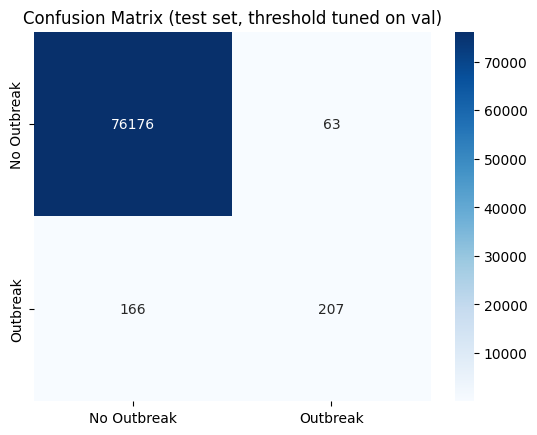

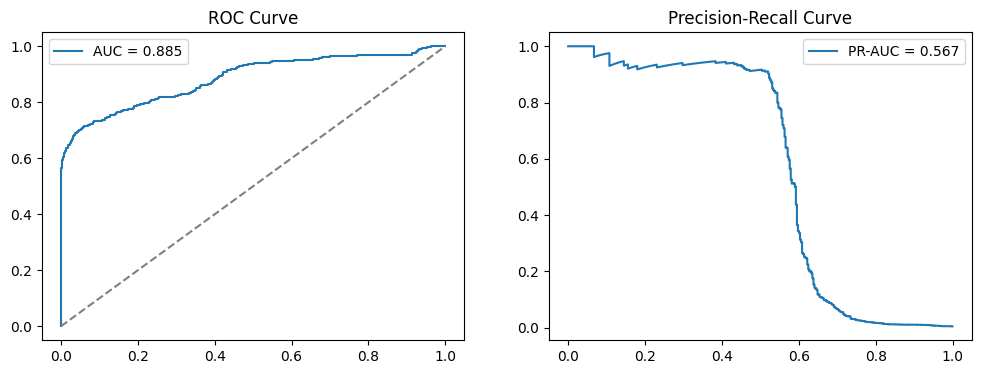

Metrics and plots saved in /content/drive/MyDrive/EPisentinel/Model 4/results


In [32]:
# Final evaluation — ENSEMBLE's averaged test probabilities, threshold frozen from validation
test_probs_per_model = [m.predict(to_input_dict(test_data), verbose=0).ravel() for m in ensemble_models]
y_prob = np.mean(test_probs_per_model, axis=0)
y_test = test_data["y"]
y_pred = (y_prob >= best_threshold).astype(int)
print(f"Averaged test probabilities across {len(ensemble_models)} models")

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_prob)
pr_auc    = average_precision_score(y_test, y_prob)
acc       = (y_pred == y_test).mean()

metrics = {"threshold_used": best_threshold, "accuracy": float(acc), "precision": float(precision),
           "recall": float(recall), "f1_score": float(f1), "roc_auc": float(auc), "pr_auc": float(pr_auc)}
print(json.dumps(metrics, indent=2))
print("\n", classification_report(y_test, y_pred, zero_division=0))

with open(f"{RES_DIR}/final_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Outbreak", "Outbreak"], yticklabels=["No Outbreak", "Outbreak"])
plt.title("Confusion Matrix (test set, threshold tuned on val)")
plt.savefig(f"{RES_DIR}/confusion_matrix.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], '--', color="gray")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
plt.savefig(f"{RES_DIR}/roc_pr_curves.png", bbox_inches="tight")
plt.show()

print("Metrics and plots saved in", RES_DIR)


{
  "outbreak_events_in_test": 37,
  "average_lead_time_weeks": 0.16216216216216217,
  "max_lead_time_weeks": 6,
  "events_with_no_warning": 36
}


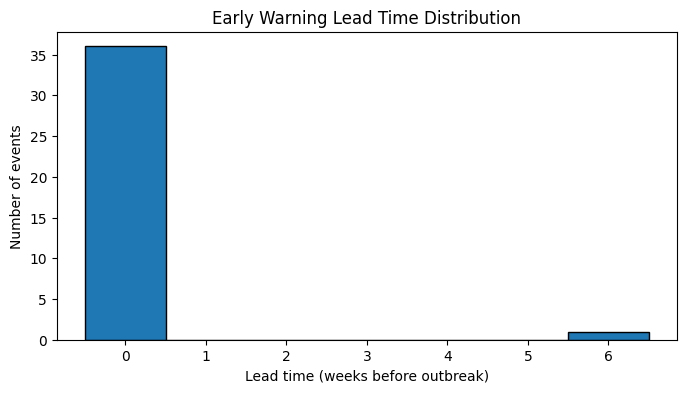

Early warning results saved -> /content/drive/MyDrive/EPisentinel/Model 4/results


In [34]:
# Final evaluation on test set — threshold is frozen from validation step
test_mask = split_all == "test"
results_df = pd.DataFrame({
    "group": group_all[test_mask], "target_date": target_dates[test_mask],
    "y_true": y_test, "y_pred": y_pred, "prob": y_prob
})

MAX_LOOKBACK = 6
lead_times = []
for keys, g in results_df.groupby("group"):
    g = g.sort_values("target_date").reset_index(drop=True)
    actual = g["y_true"].values
    preds  = g["y_pred"].values
    outbreak_starts = [i for i in range(1, len(actual)) if actual[i] == 1 and actual[i-1] == 0]
    for start in outbreak_starts:
        lead = 0
        for w in range(1, MAX_LOOKBACK + 1):
            idx = start - w
            if idx < 0:
                break
            if preds[idx] == 1:
                lead = w
        lead_times.append(lead)

ew_summary = {}
if lead_times:
    ew_summary = {
        "outbreak_events_in_test": len(lead_times),
        "average_lead_time_weeks": float(np.mean(lead_times)),
        "max_lead_time_weeks": int(max(lead_times)),
        "events_with_no_warning": int(lead_times.count(0)),
    }
    print(json.dumps(ew_summary, indent=2))

    plt.figure(figsize=(8, 4))
    plt.hist(lead_times, bins=range(0, MAX_LOOKBACK+2), align="left", edgecolor="black")
    plt.xlabel("Lead time (weeks before outbreak)")
    plt.ylabel("Number of events")
    plt.title("Early Warning Lead Time Distribution")
    plt.savefig(f"{RES_DIR}/early_warning_lead_times.png", bbox_inches="tight")
    plt.show()
else:
    ew_summary = {"outbreak_events_in_test": 0, "note": "No outbreak transitions found in the test set."}
    print(ew_summary["note"])

with open(f"{RES_DIR}/early_warning_summary.json", "w") as f:
    json.dump(ew_summary, f, indent=2)
print("Early warning results saved ->", RES_DIR)


## Summary

After running the notebook, the **Model 4** folder contains everything needed without redoing any work:
- The final model (`best_model.keras`) and the last checkpoint (`last_epoch.keras`) in case additional training is needed
- All scalers and encoders, ready for any future use (e.g. applying the model to new data)
- The final threshold, saved and selected correctly (no leakage from the test set)
- All evaluation results (metrics + plots) and the early warning summary

If the session was interrupted at any point, rerunning the notebook from the start will automatically skip any step already completed (data loading, windowing, and training will resume from the same epoch).


**v5 changes:** diseases with zero recorded outbreaks are excluded from training (set `EXCLUDE_ZERO_OUTBREAK_DISEASES = False` in the setup cell to disable), and the validation threshold is chosen with a recall-at-precision-floor strategy (falls back to F2) instead of plain F1 -- more appropriate for an early-warning system where missed outbreaks are costlier than false alarms. `MIN_PRECISION` in the threshold cell is a policy choice to revisit with the team, not a fixed technical constant.

**v6 changes:** low-signal diseases (fewer than `MIN_POSITIVE_EVENTS_PER_DISEASE` outbreak events total, e.g. Typhoid fever) are now excluded alongside the zero-outbreak ones; a CUSUM/EWMA-style `case_zscore` anomaly feature (computed strictly from the 4 lag columns, no leakage) is fed directly to the LSTM; and the final model is a 3-seed ensemble (`SEED_LIST`) with probabilities averaged before thresholding and evaluation, to reduce the variance that comes from only ~400 positive test events. Each seed checkpoints and resumes independently.